# Detailed Explanation of Lasso Regression

## What is Lasso Regression?

Lasso (Least Absolute Shrinkage and Selection Operator) is a linear regression model that uses **L1 regularization**.

The objective function:

$$
\min \left( \sum (y_i - \hat{y}_i)^2 + \alpha \sum |w_j| \right)
$$

The L1 penalty forces some coefficients to become exactly zero → automatic feature selection.


## When to Use Lasso

Use Lasso when:

* You suspect many irrelevant features
* You want automatic feature selection
* You have high-dimensional data
* Multicollinearity exists
* You prefer sparse interpretable models


## Advantages

* Performs feature selection
* Reduces overfitting
* Improves interpretability
* Works well with high-dimensional data
* Computationally efficient


## Disadvantages

* Can be unstable with highly correlated features
* Selects only one feature among correlated ones
* May underperform if true relationship is highly non-linear
* Requires proper feature scaling



## Important Hyperparameters

### alpha (Regularization Strength)

* Controls penalty strength
* Larger alpha → more shrinkage → more coefficients become zero
* Smaller alpha → behaves closer to ordinary least squares

### max_iter

* Maximum optimization iterations
* Increase if convergence warning appears

### tol

* Tolerance for stopping criteria
* Lower values increase precision but slower training


## Practical Tuning Tips

1. Always scale features before Lasso
2. Search alpha on logarithmic scale (`logspace`)
3. Use cross-validation
4. Start with wide alpha range, then refine
5. Check coefficient stability across folds
6. Consider ElasticNet if features are highly correlated
7. Inspect learning curve for bias/variance

**Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

**Load dataset**

In [4]:
data = fetch_california_housing(as_frame=True)
df = data.frame

**Data Cleaning & Exploration**

In [5]:
# Check missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [6]:
# Basic statistics
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


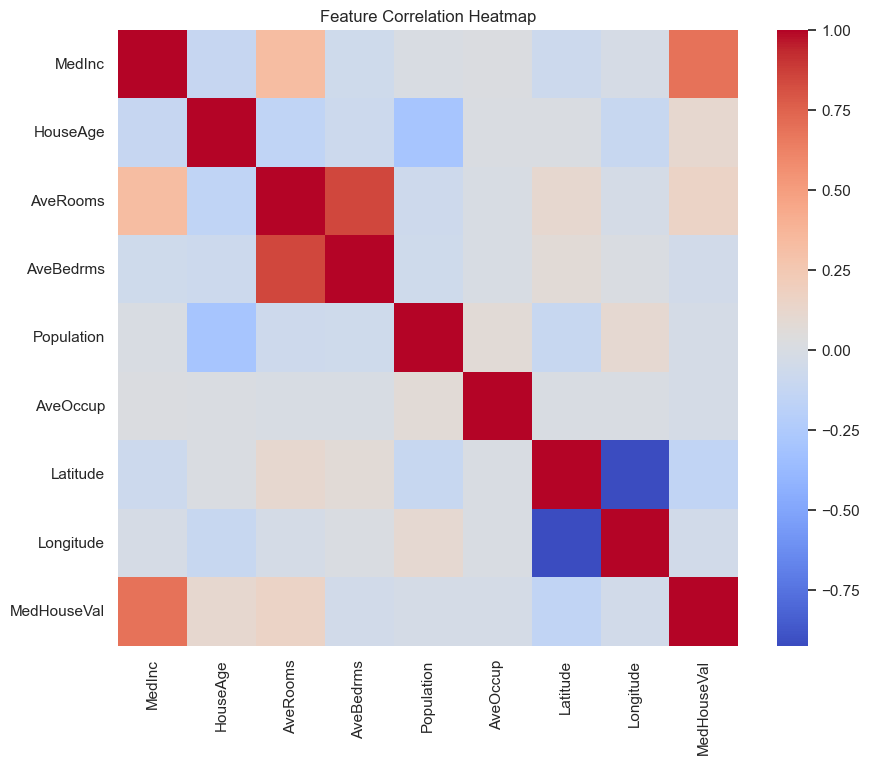

In [7]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

**Feature Engineering**

In [8]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

**Train-Test Split**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (16512, 8)
Test set size: (4128, 8)


**Create Pipeline (Scaling + Lasso)**

In [14]:
# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

**Hyperparameter Tuning with GridSearchCV**

In [15]:
param_grid = {
    'lasso__alpha': np.logspace(-4, 1, 30)
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Alpha:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Alpha: {'lasso__alpha': np.float64(0.0004893900918477494)}
Best CV Score: 0.6114961969777478


**Train Final Model**

In [16]:
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 Lasso(alpha=np.float64(0.0004893900918477494),
                       max_iter=10000))])

**Model Evaluation**

In [17]:
# Predictions
y_pred = best_model.predict(X_test)

In [18]:
# Regression Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [19]:
print("Evaluation Metrics:")
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

Evaluation Metrics:
MSE : 0.5551882490548594
RMSE: 0.745109555068823
MAE : 0.5331674842504032
R2  : 0.5763244465860213


**Feature Importance (Lasso Coefficients)**

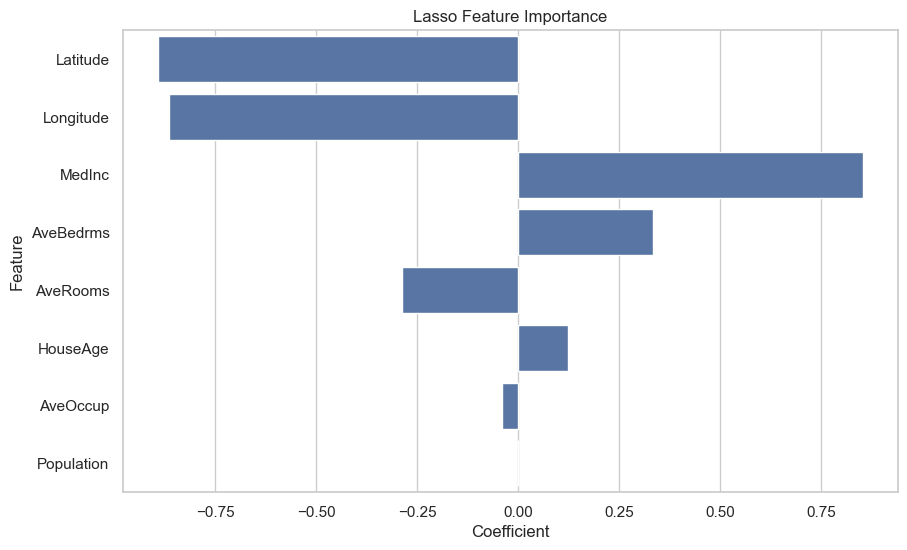

In [20]:
# Extract coefficients
coefficients = best_model.named_steps['lasso'].coef_
features = X.columns

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Coefficient", y="Feature", data=coef_df)
plt.title("Lasso Feature Importance")
plt.show()

**Residual Plot**

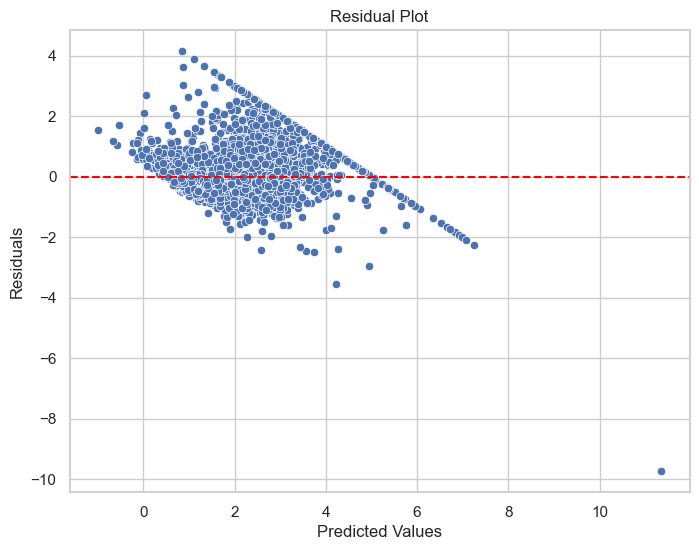

In [21]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

**Learning Curve**

In [22]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

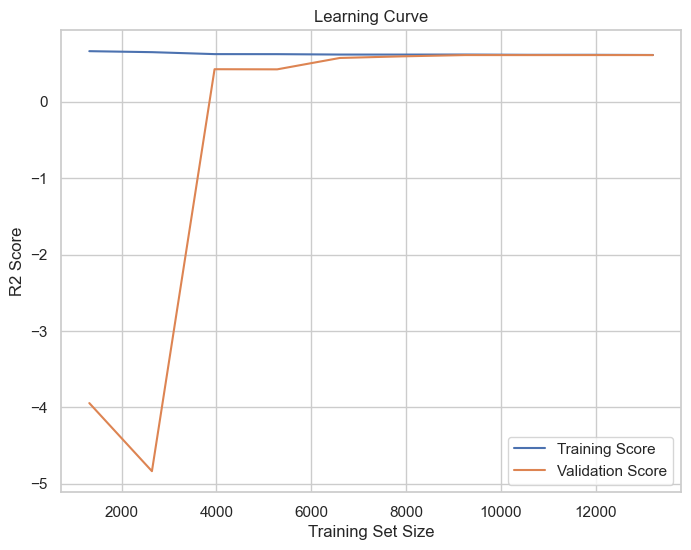

In [23]:
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")
plt.xlabel("Training Set Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve")
plt.legend()
plt.show()